## Aggregated PASTE2 Alignment
This notebook performs spot aggregation and invoking PASTE2 to perform alignments, fit affine transformations, and visualize the results.
### Preparation
Specify the file path to AnnData containing all sections, a working directory (that would be used to store intermediate results), and the aggregation radius in the following cell, then execute the remainder.

This notebook uses several common spatial transcriptomic analysis and plotting libraries: ``scanpy, pandas, matplotlib``.

In addition, This notebook requires PASTE2 codebase. You can clone the repo in the same directory as this notebook: ``https://github.com/raphael-group/paste2``, or install through ``pip install paste2``. In the latter case, you need to change the way PASTE2 is imported in the Alignment cell. 

### Notice
- Depending on the aggregation/rasterization radius, PASTE2 may run slowly. This notebook uses multiprocessing to speed up the procedure, but it may lead to Out of Memory errors on a low memory machine. In such cases, also change the related variable in the configs cell.
- This notebook excludes slice 33 and 34 by default.
- This notebook can be finished in three different runs. In each run you are required to exceute the following configuration block and data loading block. Following these two blocks:
    * First run: Aggregation and Visualization (This will perform aggregation of spots and save results to data folder)
    * Second run: Alignment (This will perform PASTE2 alignment and save results to data folder). This can also be restarted multiple times; Pair alignment are run in parallel and saved to disk as soon as it finishes.
    * Final run: Visualization (This will perform the affine alignment, visualize HPF cells, and save transformed coordinates as a CSV file)
## Configuration Block

In [1]:
# File path to aggregated AnnData object
ad_fn = "/n/fs/ragr-data/users/hz7140/external/Xenium_update_anno.h5ad"
# Folder to save per-slice AnnData objects and alignment matrices. Make sure it exists.
base_fd = "/n/fs/ragr-data/users/hz7140/multimodal_alignment/post-nbt/1121-daisy-package/data/"
# Aggregation radius for alignment.
aggr_radius = 120
# Number of parallel processes for paste2 alignment. Set this according to computing resources.
paste2_processes = 20

### Data Loading and Splitting

In [2]:
import anndata
import scanpy as sc
import numpy as np
import pandas as pd
import os
data = anndata.read_h5ad(ad_fn)
# These are for later visualizations.
subset = 'CA3|CA1|SUB|DG|CA2'
data.obs['Subcortex_Group_v4'] = data.obs['Subcortex_Group_v4'].astype(str)
data.obsm['spatial'] = data.obs[['x', 'y']].to_numpy()
data_HPF = data[data.obs['Subcortex_Group_v4'].str.contains(subset), :]

slices_full = []
for i, cat in enumerate(data.obs['brain_section_barcode'].unique()):
    slices_full.append(data[data.obs['brain_section_barcode'] == cat].copy())

### Aggregation

In [6]:
def min_xenium_to_spot(xe, aggr_dist, redo_coord = True, min_weight = 2):
    '''
    Create a pseudo-spot-aggregated data. 
    '''
    from scipy.spatial import KDTree
    minx, maxx = min(xe.obsm['spatial'][:, 0]), max(xe.obsm['spatial'][:, 0])
    miny, maxy = min(xe.obsm['spatial'][:, 1]), max(xe.obsm['spatial'][:, 1])
    nr = int((maxx - minx) / aggr_dist) + 1
    nc = int((maxy - miny) / aggr_dist) + 1
    pts = []
    for i in range(nr):
        for j in range(nc):
            pts.append((minx + aggr_dist * i, miny + aggr_dist * j))
    kdt = KDTree(pts)
    ret = anndata.AnnData(np.zeros((len(pts), xe.shape[1])))
    ret.var_names = xe.var_names[:]
    ret.var = xe.var.copy()
    ret.uns = xe.uns.copy()
    if not redo_coord:
        ret.obsm['spatial'] = np.array(pts)
    else:
        ret.obsm['spatial'] = np.zeros((len(pts), 2))
        ret.obsm['_spatial_seed'] = np.array(pts)
    ret.obs['weight'] = np.zeros(len(pts))
    xe_mat = xe.X.toarray() if not isinstance(xe.X, np.ndarray) else xe.X
    weight_loc = ret.obs.columns.get_loc('weight')
    for i in range(xe.shape[0]):
        _, spot = kdt.query(xe.obsm['spatial'][i])
        ret.X[spot] += xe_mat[i]
        w = 1 # sum(xe_mat[i])
        ret.obs.iloc[spot, weight_loc] += w
        if redo_coord:
            ret.obsm['spatial'][spot] += w * xe.obsm['spatial'][i]
    ret = ret[ret.obs['weight'] >= min_weight].copy()
    if redo_coord:
        ret.obsm['spatial'] = np.asarray(ret.obsm['spatial']) / np.asarray(ret.obs['weight'])[:, np.newaxis]  # Wrappers??
    # Remove empty spots
    return ret

slices_aggr = []
for i, data in enumerate(slices_full):
    print(f"Processing slice {i+1}/{len(slices_full)} ...")
    slice_aggr = min_xenium_to_spot(data, aggr_radius)
    slices_aggr.append(slice_aggr)
    print(f"Done. Original n={data.n_obs}, aggregated n={slice_aggr.n_obs}")

Processing slice 1/47 ...
Done. Original n=46339, aggregated n=3048
Processing slice 2/47 ...
Done. Original n=52065, aggregated n=3425
Processing slice 3/47 ...
Done. Original n=59633, aggregated n=3616
Processing slice 4/47 ...
Done. Original n=58107, aggregated n=3808
Processing slice 5/47 ...
Done. Original n=61141, aggregated n=3955
Processing slice 6/47 ...
Done. Original n=81491, aggregated n=3876
Processing slice 7/47 ...
Done. Original n=66837, aggregated n=4534
Processing slice 8/47 ...
Done. Original n=65972, aggregated n=4669
Processing slice 9/47 ...
Done. Original n=68131, aggregated n=4905
Processing slice 10/47 ...
Done. Original n=77075, aggregated n=5136
Processing slice 11/47 ...
Done. Original n=84158, aggregated n=5471
Processing slice 12/47 ...
Done. Original n=78294, aggregated n=5332
Processing slice 13/47 ...
Done. Original n=87976, aggregated n=6005
Processing slice 14/47 ...
Done. Original n=99165, aggregated n=6141
Processing slice 15/47 ...
Done. Original n

### Visualizing rasterized slices and saving aggregated AnnData to disk

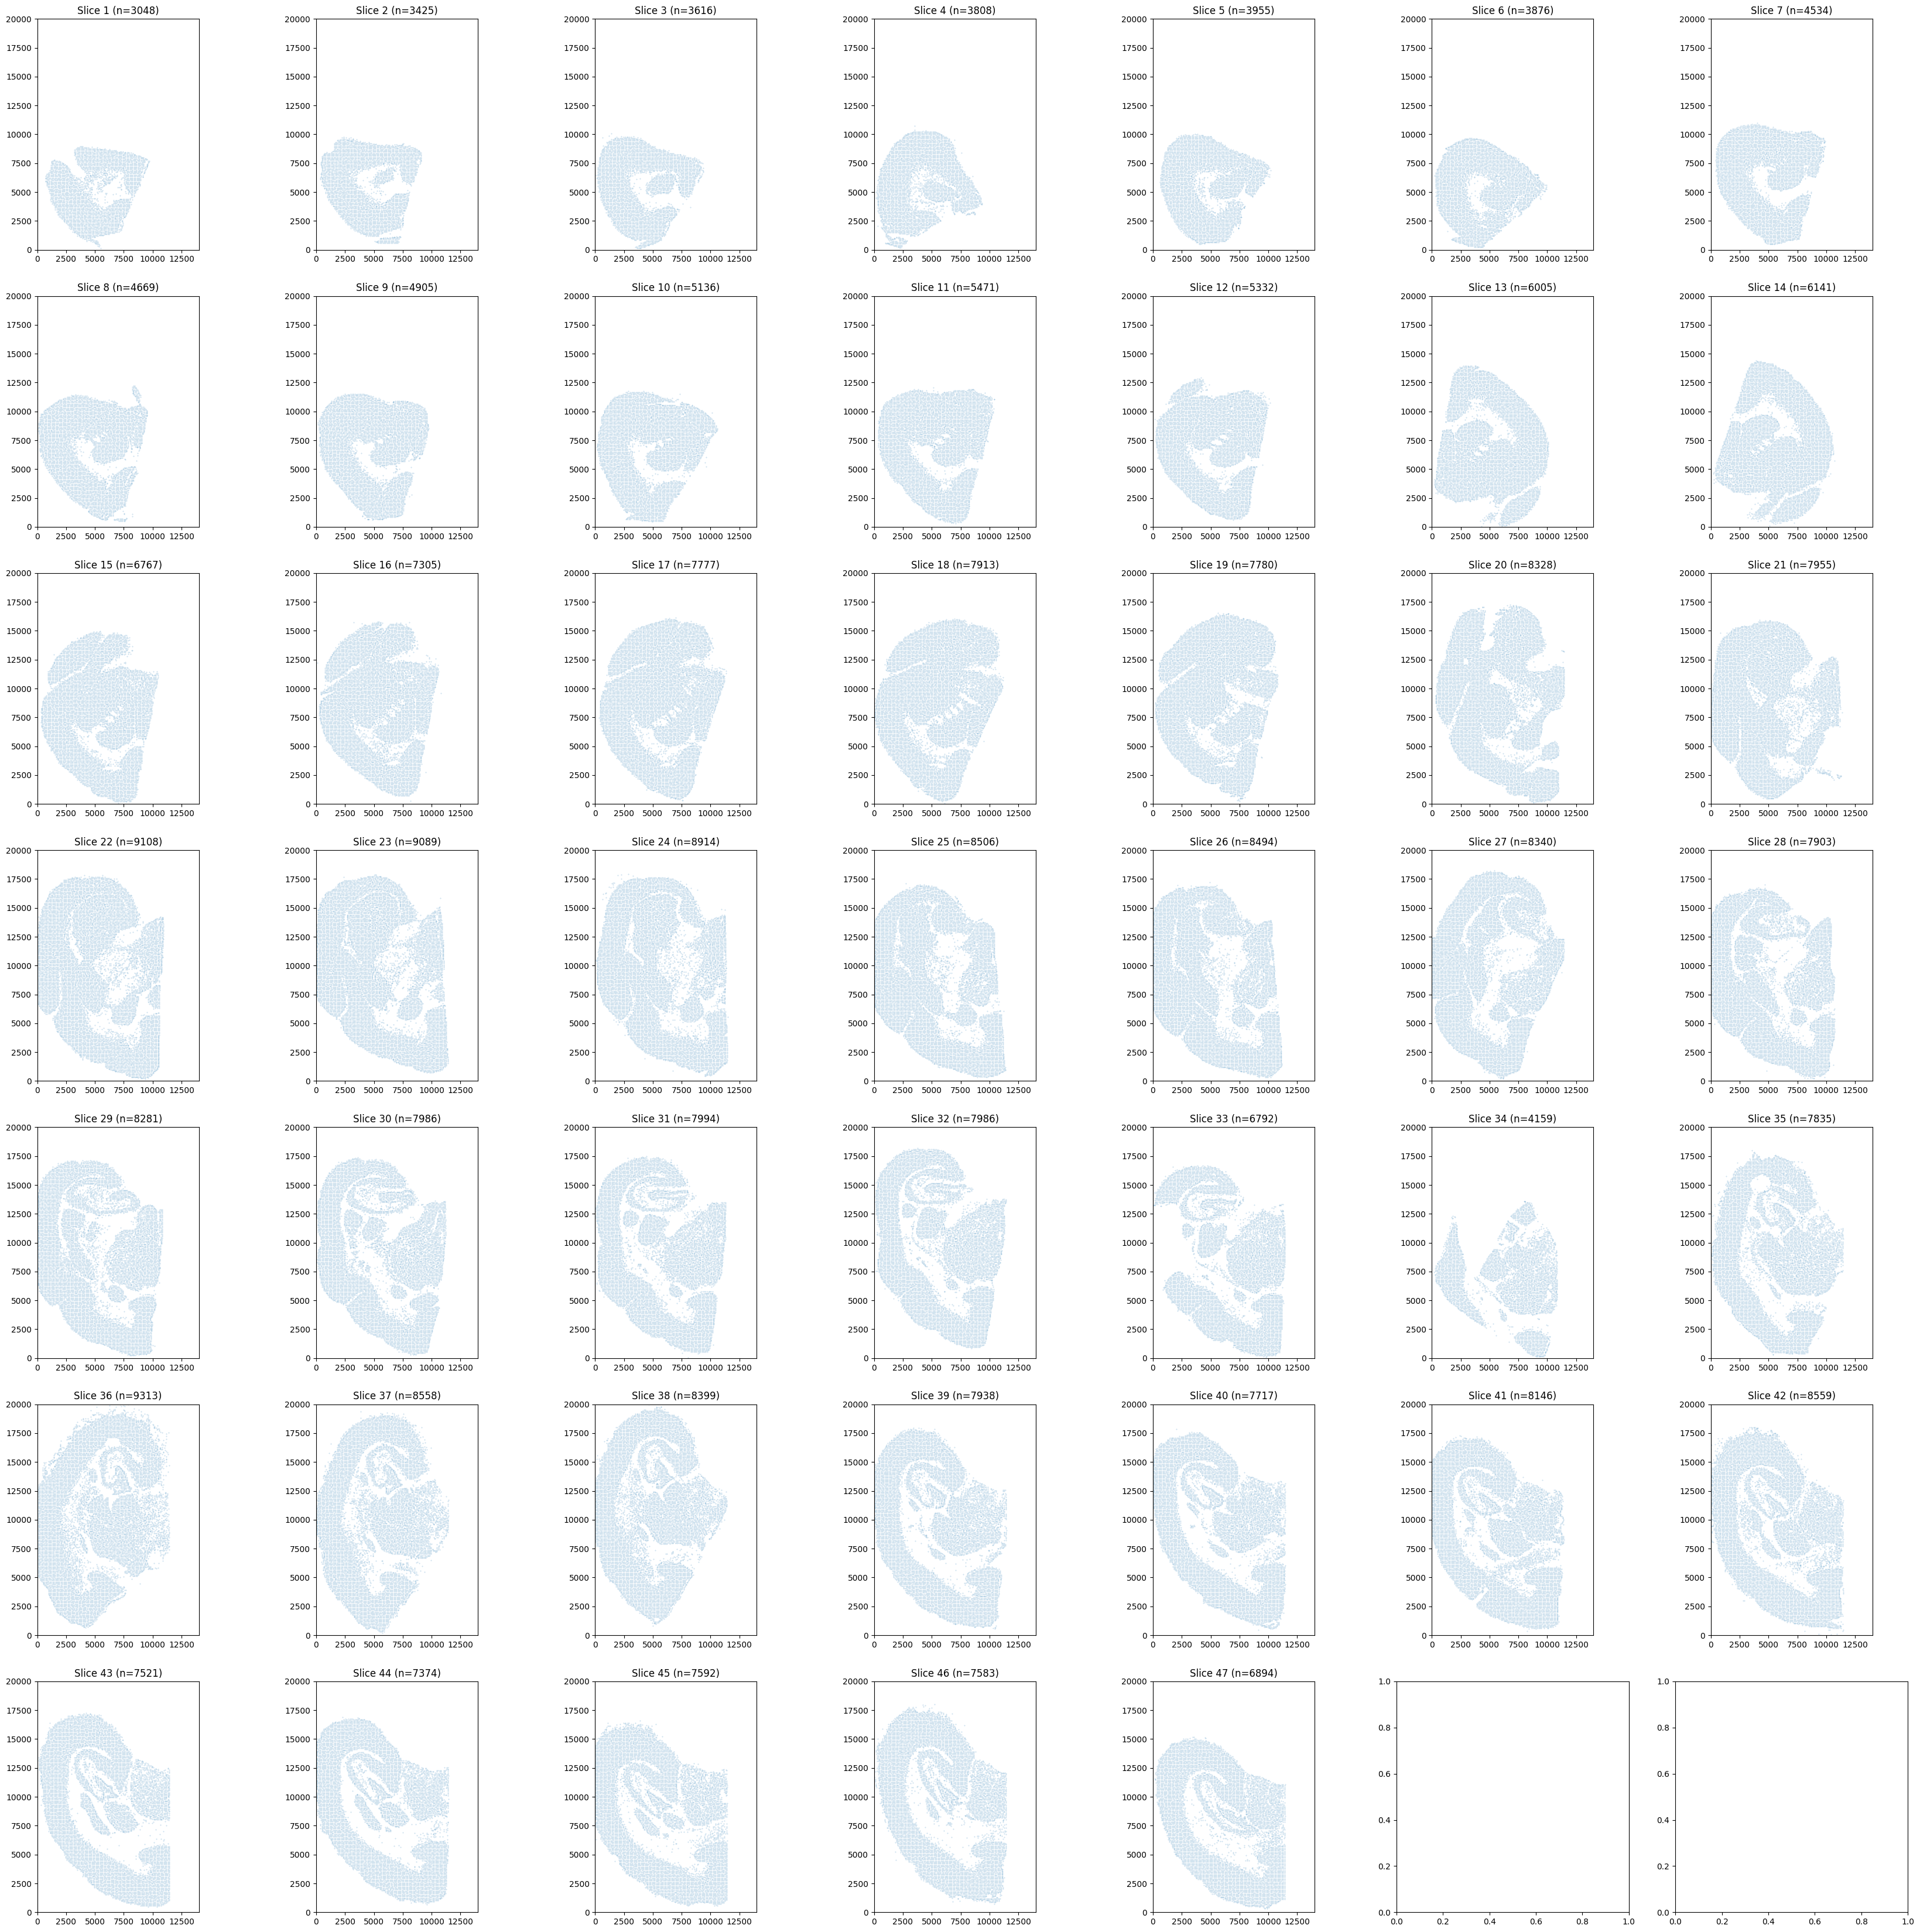

In [7]:
import scanpy as sc
import matplotlib.pyplot as plt
_, subplots = plt.subplots(7, 7, figsize = (42, 42))
subplots = subplots.flatten()
for i, slice in enumerate(slices_aggr):
    subplots[i].scatter(slice.obsm['spatial'][:, 0], slice.obsm['spatial'][:, 1], s=0.1, alpha=0.4)
    subplots[i].set_aspect("equal")
    subplots[i].set_title(f"Slice {i+1} (n={slice.n_obs})")
    subplots[i].set_xlim(0, 14000)
    subplots[i].set_ylim(0, 20000)
    slice.write_h5ad(f"{base_fd}/{i}_r{aggr_radius}.h5ad")
plt.show()

### Alignment

This cell performs PASTE2 alignment of adjacent aggregated slices in parallel. The PASTE2 outputs are redirected to log files in the data directory specified in the configuration cell. 

### Notice
Alignment outputs (coupling matrices) are written to disk as soon as it finishes, so you could restart the cell if it won't finish in one run.

In [3]:
# change this line accordingly if you install PASTE2 through PyPI or other package managers.
from paste2.src.paste2 import PASTE2
from contextlib import redirect_stderr, redirect_stdout
import anndata
import numpy as np
import multiprocessing as mp
import os
import time

class AutoFlush:
    def __init__(self, fp):
        self.fp = fp

    def write(self, data):
        out = self.fp.write(data)
        self.fp.flush()
        return out

    def flush(self):
        self.fp.flush()

def hpf_align(idx1, idx2, diss):
    out_fn = f"{base_fd}/{idx1}_{idx2}_{diss}_r{aggr_radius}.npy"
    log_fn = f"{base_fd}/{idx1}_{idx2}_{diss}_r{aggr_radius}.log"
    if os.path.exists(out_fn):
        print(f"skipping: {out_fn}\n", flush=True)
        return
    else:
        print(f"processing: {out_fn}\n", flush=True)
        start_time = time.time()
    slice1 = anndata.read_h5ad(f"{base_fd}/{idx1}_r{aggr_radius}.h5ad")
    slice2 = anndata.read_h5ad(f"{base_fd}/{idx2}_r{aggr_radius}.h5ad")
    marginal1 = slice1.obs['weight'] / slice1.obs['weight'].sum()
    marginal2 = slice2.obs['weight'] / slice2.obs['weight'].sum()
    with open(log_fn, 'w') as log_f:
        with redirect_stdout(AutoFlush(log_f)), redirect_stderr(AutoFlush(log_f)):
            pi_AB = PASTE2.partial_pairwise_align(slice1, slice2, s=0.9, a_distribution=marginal1, b_distribution=marginal2, dissimilarity=diss)
    np.save(out_fn, pi_AB)
    print(f"finished: {out_fn} in {time.time() - start_time:.2f} seconds\n", flush=True)

eligible_idx = list(x for x in range(47) if x not in [32, 33])
eligible_configs_pca = [(eligible_idx[i], eligible_idx[i+1], 'pca') for i in range(len(eligible_idx)-1) ]
with mp.Pool(paste2_processes) as pool:
    pool.starmap(hpf_align, eligible_configs_pca)

skipping: /n/fs/ragr-data/users/hz7140/multimodal_alignment/post-nbt/1121-daisy-package/data//1_2_pca_r120.npy
skipping: /n/fs/ragr-data/users/hz7140/multimodal_alignment/post-nbt/1121-daisy-package/data//4_5_pca_r120.npy
skipping: /n/fs/ragr-data/users/hz7140/multimodal_alignment/post-nbt/1121-daisy-package/data//0_1_pca_r120.npy
skipping: /n/fs/ragr-data/users/hz7140/multimodal_alignment/post-nbt/1121-daisy-package/data//3_4_pca_r120.npy
skipping: /n/fs/ragr-data/users/hz7140/multimodal_alignment/post-nbt/1121-daisy-package/data//2_3_pca_r120.npy
skipping: /n/fs/ragr-data/users/hz7140/multimodal_alignment/post-nbt/1121-daisy-package/data//7_8_pca_r120.npy
skipping: /n/fs/ragr-data/users/hz7140/multimodal_alignment/post-nbt/1121-daisy-package/data//6_7_pca_r120.npy
skipping: /n/fs/ragr-data/users/hz7140/multimodal_alignment/post-nbt/1121-daisy-package/data//5_6_pca_r120.npy
skipping: /n/fs/ragr-data/users/hz7140/multimodal_alignment/post-nbt/1121-daisy-package/data//8_9_pca_r120.npy
s

### Transforming coordinates for future use
After all alignments are finalized, this cell loads the computed alignments, computes transformation between adjacent slices and transform all cells into a common coordinate.

In [4]:
import matplotlib.pyplot as plt
from paste2.src.paste2 import projection
import numpy as np
import pandas as pd

def plot_slices_overlap(slices, save=False, save_path=None, ax_=None):
    if ax_ is None:
        _, ax = plt.subplots(figsize=(5, 5))
    else:
        ax = ax_
    for i in range(len(slices)):
        adata = slices[i]
        ax.scatter(
            adata.obsm["spatial"][:, 0],
            adata.obsm["spatial"][:, 1],
            linewidth=0,
            s=10,
            marker=".",
            alpha=0.5,
        )
    ax.invert_yaxis()
    ax.set_aspect("equal")
    # ax.axis("off")
    if ax_ is None:
        plt.show()
    if save and save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
def largest_indices(ary, n):
    """Returns the n largest indices from a numpy array."""
    flat = ary.flatten()
    indices = np.argpartition(flat, -n)[-n:]
    indices = indices[np.argsort(-flat[indices])]
    return np.unravel_index(indices, ary.shape)


def plot2D_samples_mat(xs, xt, G, thr=1e-8, alpha=0.2, top=1000, weight_alpha=False, **kwargs):
    if ('color' not in kwargs) and ('c' not in kwargs):
        kwargs['color'] = 'k'
    mx = G.max()
    #     idx = np.where(G/mx>=thr)
    idx = largest_indices(G, top)
    print(len(idx[0]))
    for l in range(len(idx[0])):
        plt.plot([xs[idx[0][l], 0], xt[idx[1][l], 0]], [xs[idx[0][l], 1], xt[idx[1][l], 1]],
                 alpha=alpha * (1 - weight_alpha) + (weight_alpha * G[idx[0][l], idx[1][l]] / mx), c='k')


def plot_slice_pairwise_alignment_nolabel(slice1, slice2, pi, thr=1 - 1e-8, alpha=0.05, top=1000, name='', save=False,
                                  weight_alpha=False):
    coordinates1, coordinates2 = slice1.obsm['spatial'], slice2.obsm['spatial']
    offset = (coordinates1[:, 0].max() - coordinates2[:, 0].min()) * 1.1
    temp = np.zeros(coordinates2.shape)
    temp[:, 0] = offset
    plt.figure(figsize=(20, 10))
    plot2D_samples_mat(coordinates1, coordinates2 + temp, pi, thr=thr, c='k', alpha=alpha, top=top,
                       weight_alpha=weight_alpha)
    plt.scatter(coordinates1[:, 0], coordinates1[:, 1], linewidth=0, s=5, marker=".")
    plt.scatter(coordinates2[:, 0] + offset, coordinates2[:, 1], linewidth=0, s=5, marker=".")
    plt.gca().invert_yaxis()
    # plt.axis('off')
    plt.gca().set_aspect('equal')
    plt.show()

def transform_coordinates(coords, transformation_matrix):
    homogeneous_coords = np.hstack([coords, np.ones((coords.shape[0], 1))])
    transformed_homogeneous = homogeneous_coords @ transformation_matrix.T
    transformed_coords = transformed_homogeneous[:, :2] / transformed_homogeneous[:, 2][:, np.newaxis]
    return transformed_coords

def lstsq_proj_mat(sp1, sp2, pi):
    '''
    Uses Least Squares to calculate a affine transformation.
    The loss function is \sum w_{ij} |Rx_i - y_j|_2^2. 
    The 6 free parameters denote the upper two rows of R.
    The expected transformation is Y = RX.
    '''
    nnz = np.sum(pi > 0)
    A = np.zeros((2 * nnz, 6))
    B = np.zeros(2 * nnz)
    l = 0
    for i in range(pi.shape[0]):
        for j in range(pi.shape[1]):
            if pi[i][j] > 0:
                w = pi[i][j] ** 0.5
                x1, y1 = sp1[i]
                x2, y2 = sp2[j]
                A[l] = [x1 * w, y1 * w, w, 0, 0, 0]
                A[l + 1] = [0, 0, 0, x1 * w, y1 * w, w]
                B[l] = x2 * w
                B[l + 1] = y2 * w
                l += 2
    return A, B


def lstsq_proj(sp1, sp2, pi):
    from scipy.linalg import lstsq
    A, B = lstsq_proj_mat(sp1, sp2, pi)
    T, _, _, _ = lstsq(A, B)
    return np.append(T, [0, 0, 1]).reshape(3, 3)

def svd_proj(sp1, sp2, pi):
    nnz = np.sum(pi > 0)
    print(nnz, sp1.shape, sp2.shape)
    X = np.zeros((2, nnz))
    Y = np.zeros((2, nnz))
    W = np.zeros((nnz, 1))
    l = 0
    for i, j in zip(*np.nonzero(pi > 0)):
        w = pi[i][j]
        X[:, l] = sp1[i]
        Y[:, l] = sp2[j]
        W[l] = w
        l += 1
    X_cen = (np.sum(X.T * W, axis = 0) / np.sum(W))
    Y_cen = (np.sum(Y.T * W, axis = 0) / np.sum(W))
    # print(X_cen, Y_cen)
    H = ((X - X_cen.reshape(-1, 1)) * W.T).dot(Y.T - Y_cen)
    U, S, Vt = np.linalg.svd(H)
    R = Vt.T.dot(U.T)
    # Make into 3x3
    s = Y_cen - R.dot(X_cen)
    return np.array([[R[0, 0], R[0, 1], s[0]], [R[1, 0], R[1, 1], s[1]], [0, 0, 1]])

incl_barcodes = list(data_HPF.obs['brain_section_barcode'].unique())
incl_barcodes = incl_barcodes[:32] + incl_barcodes[34:]

incl_ids = list(x for x in range(47) if x not in [32, 33])
slices = [anndata.read_h5ad(f"{base_fd}/{i}_r{aggr_radius}.h5ad") for i in incl_ids]
pis = [np.load(f"{base_fd}/{incl_ids[x]}_{incl_ids[x+1]}_pca_r{aggr_radius}.npy") for x in range(len(incl_ids) - 1)]

# compute transfomations for each pair
rigid_tfs = []
for i in range(len(slices) - 1):
    print(i)
    sp1 = slices[i].obsm['spatial']
    sp2 = slices[i + 1].obsm['spatial']
    pi = pis[i]
    tf = svd_proj(sp1, sp2, pi)
    rigid_tfs.append(tf)



dfs = []
for i in range(len(slices)):
    cur_cells = data[data.obs['brain_section_barcode'] == incl_barcodes[i], :]
    cur_sp = cur_cells.obs[['x', 'y']].copy()
    for j in range(i, len(rigid_tfs)):
        cur_sp = transform_coordinates(cur_sp, rigid_tfs[j])
    cur_sp = transform_coordinates(cur_sp, np.eye(3)) # match format
    df = pd.DataFrame({
        'brain_section_barcode': cur_cells.obs['brain_section_barcode'],
        'x': cur_sp[:, 0],
        'y': cur_sp[:, 1]
    }, index=cur_cells.obs_names)
    dfs.append(df)
    
combined_df = pd.concat(dfs)
print(combined_df.head())
combined_df.to_csv(f"{base_fd}/combined_transformed_coordinates.csv", index=True)

<>:72: SyntaxWarning: invalid escape sequence '\s'
<>:72: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4165500/3772562586.py:72: SyntaxWarning: invalid escape sequence '\s'
  '''


0
5234 (3048, 2) (3425, 2)
1
5707 (3425, 2) (3616, 2)
2
5813 (3616, 2) (3808, 2)
3
6303 (3808, 2) (3955, 2)
4
6617 (3955, 2) (3876, 2)
5
7285 (3876, 2) (4534, 2)
6
8060 (4534, 2) (4669, 2)
7
8520 (4669, 2) (4905, 2)
8
8177 (4905, 2) (5136, 2)
9
9060 (5136, 2) (5471, 2)
10
8970 (5471, 2) (5332, 2)
11
9265 (5332, 2) (6005, 2)
12
9947 (6005, 2) (6141, 2)
13
10795 (6141, 2) (6767, 2)
14
11163 (6767, 2) (7305, 2)
15
12004 (7305, 2) (7777, 2)
16
12299 (7777, 2) (7913, 2)
17
12361 (7913, 2) (7780, 2)
18
13461 (7780, 2) (8328, 2)
19
13893 (8328, 2) (7955, 2)
20
14683 (7955, 2) (9108, 2)
21
14408 (9108, 2) (9089, 2)
22
13981 (9089, 2) (8914, 2)
23
13750 (8914, 2) (8506, 2)
24
13284 (8506, 2) (8494, 2)
25
13399 (8494, 2) (8340, 2)
26
13129 (8340, 2) (7903, 2)
27
12871 (7903, 2) (8281, 2)
28
12923 (8281, 2) (7986, 2)
29
12033 (7986, 2) (7994, 2)
30
12098 (7994, 2) (7986, 2)
31
13189 (7986, 2) (7835, 2)
32
13319 (7835, 2) (9313, 2)
33
13410 (9313, 2) (8558, 2)
34
12433 (8558, 2) (8399, 2)
35
12714

### HPF cell visualization
This is an extra cell just to visualize HPF cells. For visualization purposes, this contains an optional rotation around the center of a specific slice.

Transformation Matrix:
[[ 2.58819045e-01 -9.65925826e-01  1.71291332e+04]
 [ 9.65925826e-01  2.58819045e-01  2.17008514e+03]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]


(0.0, 20000.0)

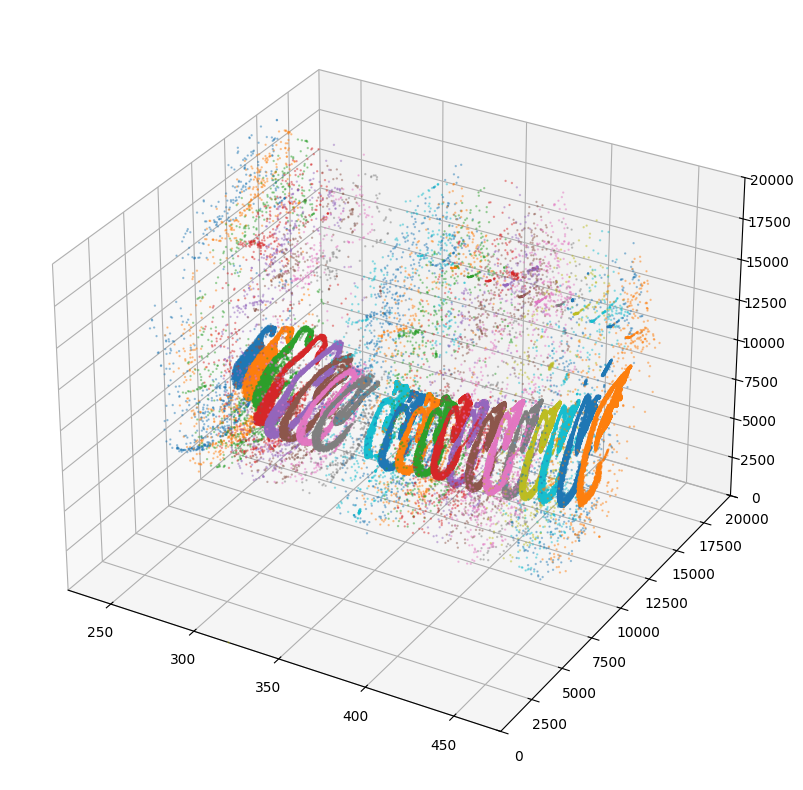

In [5]:
transformed_hpf_coords = []
for i in range(len(slices)):
    hpf_cells = data_HPF[data_HPF.obs['brain_section_barcode'] == incl_barcodes[i], :]
    sp_hpf = hpf_cells.obs[['x', 'y']].copy()
    for j in range(i, len(rigid_tfs)):
        sp_hpf = transform_coordinates(sp_hpf, rigid_tfs[j])
    sp_hpf = transform_coordinates(sp_hpf, np.eye(3)) # match format
    transformed_hpf_coords.append(sp_hpf)

hpf_3d_coords = []
interval = 10
for i in range(len(transformed_hpf_coords)):
    hpf_3d_coords.append(np.hstack((
        transformed_hpf_coords[i],
        incl_ids[i] * 1.0 * interval * np.ones((transformed_hpf_coords[i].shape[0], 1))
    )))

fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(projection='3d')
# Calculate the center of mass for transformed_hpf_coords[23]
center = np.mean(transformed_hpf_coords[23], axis=0)

# Define the rotation angle (clockwise rotation means negative angle)
theta = np.deg2rad(75)
cos_t, sin_t = np.cos(theta), np.sin(theta)

# Create the 3x3 rotation matrix about the origin
R = np.array([
    [cos_t, -sin_t, 0],
    [sin_t,  cos_t, 0],
    [0,      0,     1]
])

# Create translation matrices to move the center to the origin and back
T_neg = np.array([
    [1, 0, -center[0]],
    [0, 1, -center[1]],
    [0, 0, 1]
])
T_pos = np.array([
    [1, 0, center[0]],
    [0, 1, center[1]],
    [0, 0, 1]
])

# Construct the overall transformation matrix (translate, rotate, translate back)
transformation_matrix = T_pos @ R @ T_neg

print("Transformation Matrix:")
print(transformation_matrix)
for i in range(24, len(hpf_3d_coords)):
    if i == 32:
        ax.scatter([320], [0], [0], s = 0.1)
    current_pts = hpf_3d_coords[i].copy()
    current_pts[:, :2] = transform_coordinates(current_pts[:, :2], transformation_matrix)
    ax.scatter(
        current_pts[:, 2],
        current_pts[:, 1],
        current_pts[:, 0],
        s = 0.5,
        alpha=0.4
    )
ax.set_ylim3d(0, 20000)
ax.set_zlim3d(0, 20000)
